# Imports and Setup

In [108]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

print("All imports successful")
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Num CPUs Available:", len(tf.config.list_physical_devices('CPU')))

All imports successful
TensorFlow version: 2.16.2
Num GPUs Available: 1
Num CPUs Available: 1


In [109]:
print("TensorFlow version:", tf.__version__)

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

print("Num CPUs Available:", len(tf.config.list_physical_devices('CPU')))

TensorFlow version: 2.16.2
Num GPUs Available: 1
Num CPUs Available: 1


# Data Loading and Initial Setup

In [110]:
df = pd.read_csv("data/metadata")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [111]:
image_dir = "data/images"

df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(image_dir, x + ".jpg")
)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,data/images/ISIC_0031633.jpg


In [112]:
print("Missing images:", df["image_path"].apply(lambda x: not os.path.exists(x)).sum())

Missing images: 0


In [113]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'dataset', 'image_path'],
      dtype='object')

In [114]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

# Data Cleaning and Preprocessing

In [115]:
df_model = df[['image_path', 'dx', 'age', 'localization']].copy()
df_model.head()

,image_path,dx,age,localization
0,data/images/ISIC_0027419.jpg,bkl,80.0,scalp
1,data/images/ISIC_0025030.jpg,bkl,80.0,scalp
2,data/images/ISIC_0026769.jpg,bkl,80.0,scalp
3,data/images/ISIC_0025661.jpg,bkl,80.0,scalp
4,data/images/ISIC_0031633.jpg,bkl,75.0,ear


In [116]:
df_model.isnull().sum()

image_path       0
dx               0
age             57
localization     0
dtype: int64

In [117]:
df_model["age"] = df["age"].fillna(df["age"].median())

In [118]:
df_model = pd.get_dummies(df_model, columns=['localization'])

le = LabelEncoder()
df_model['dx'] = le.fit_transform(df_model['dx'])

In [119]:
for i, class_name in enumerate(le.classes_):
    print(i, ":", class_name)

0 : akiec
1 : bcc
2 : bkl
3 : df
4 : mel
5 : nv
6 : vasc


In [120]:
y = df_model["dx"]

X_meta = df_model.drop(columns=['image_path', 'dx'])

In [121]:
df_model.head()

,image_path,dx,age,localization_abdomen,localization_acral,localization_back,localization_chest,localization_ear,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity
0,data/images/ISIC_0027419.jpg,2,80.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,data/images/ISIC_0025030.jpg,2,80.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,data/images/ISIC_0026769.jpg,2,80.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,data/images/ISIC_0025661.jpg,2,80.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,data/images/ISIC_0031633.jpg,2,75.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


# Multimodal Classifier

## Stratified K-Fold Cross-Validation

In [122]:
y = df_model["dx"]
X_images = df_model["image_path"]
X_meta = df_model.drop(columns=['image_path', 'dx'])

print("Metadata shape:", X_meta.shape)
print("Images:", X_images.shape)
print("Labels:", y.shape)

Metadata shape: (10015, 16)
Images: (10015,)
Labels: (10015,)


In [123]:
bool_cols = X_meta.select_dtypes(include=["bool"]).columns
X_meta[bool_cols] = X_meta[bool_cols].astype(int)

In [124]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [125]:
folds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta, y), start=1):
    fold_data = {
        "fold": fold,
        "X_meta_train": X_meta.iloc[train_idx].reset_index(drop=True),
        "X_meta_val": X_meta.iloc[val_idx].reset_index(drop=True),
        "X_img_train": X_images.iloc[train_idx].reset_index(drop=True),
        "X_img_val": X_images.iloc[val_idx].reset_index(drop=True),
        "y_train": y.iloc[train_idx].reset_index(drop=True),
        "y_val": y.iloc[val_idx].reset_index(drop=True)
    }
    folds.append(fold_data)
print("Number of folds saved:", len(folds))

Number of folds saved: 5


## Image Preprocessing and Feature Extraction

In [126]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
    pooling="avg"
)

print("Model loaded")

Model loaded


In [127]:
"""
extract_features(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))

    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    features = base_model.predict(img_array, verbose=0)
    return features[0]
"""

In [1]:
"""
def load_and_preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    return preprocess_input(img_array)
"""

def extract_features_batch(image_paths, batch_size=32):
    all_features = []
    
    for start in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[start:start + batch_size]
        batch_images = np.array([load_and_preprocess_image(p) for p in batch_paths])
        
        batch_features = base_model.predict(batch_images, verbose=0)
        all_features.append(batch_features)
    
    return np.vstack(all_features)

## Multimodal Classifier and Evaluation


--- Fold 1 ---


2026-04-12 16:33:50.855079: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Processed 16 / 8012
Processed 32 / 8012
Processed 48 / 8012
Processed 64 / 8012
Processed 80 / 8012
Processed 96 / 8012
Processed 112 / 8012
Processed 128 / 8012
Processed 144 / 8012
Processed 160 / 8012
Processed 176 / 8012
Processed 192 / 8012
Processed 208 / 8012
Processed 224 / 8012
Processed 240 / 8012
Processed 256 / 8012
Processed 272 / 8012
Processed 288 / 8012
Processed 304 / 8012
Processed 320 / 8012
Processed 336 / 8012
Processed 352 / 8012
Processed 368 / 8012
Processed 384 / 8012
Processed 400 / 8012
Processed 416 / 8012
Processed 432 / 8012
Processed 448 / 8012
Processed 464 / 8012
Processed 480 / 8012
Processed 496 / 8012
Processed 512 / 8012
Processed 528 / 8012
Processed 544 / 8012
Processed 560 / 8012
Processed 576 / 8012
Processed 592 / 8012
Processed 608 / 8012
Processed 624 / 8012
Processed 640 / 8012
Processed 656 / 8012
Processed 672 / 8012
Processed 688 / 8012
Processed 704 / 8012
Processed 720 / 8012
Processed 736 / 8012
Processed 752 / 8012
Processed 768 / 801

2026-04-12 16:37:53.780838: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Processed 8012 / 8012
Processed 16 / 2003
Processed 32 / 2003
Processed 48 / 2003
Processed 64 / 2003
Processed 80 / 2003
Processed 96 / 2003
Processed 112 / 2003
Processed 128 / 2003
Processed 144 / 2003
Processed 160 / 2003
Processed 176 / 2003
Processed 192 / 2003
Processed 208 / 2003
Processed 224 / 2003
Processed 240 / 2003
Processed 256 / 2003
Processed 272 / 2003
Processed 288 / 2003
Processed 304 / 2003
Processed 320 / 2003
Processed 336 / 2003
Processed 352 / 2003
Processed 368 / 2003
Processed 384 / 2003
Processed 400 / 2003
Processed 416 / 2003
Processed 432 / 2003
Processed 448 / 2003
Processed 464 / 2003
Processed 480 / 2003
Processed 496 / 2003
Processed 512 / 2003
Processed 528 / 2003
Processed 544 / 2003
Processed 560 / 2003
Processed 576 / 2003
Processed 592 / 2003
Processed 608 / 2003
Processed 624 / 2003
Processed 640 / 2003
Processed 656 / 2003
Processed 672 / 2003
Processed 688 / 2003
Processed 704 / 2003
Processed 720 / 2003
Processed 736 / 2003
Processed 752 / 20

...

251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.3246 - loss: 1.8212 

2026-04-12 18:07:56.247208: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


251/251 ━━━━━━━━━━━━━━━━━━━━ 235s 916ms/step - accuracy: 0.4015 - loss: 1.6003 - val_accuracy: 0.6151 - val_loss: 1.0779
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5347 - loss: 1.2291 - val_accuracy: 0.5507 - val_loss: 1.1669
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5609 - loss: 1.0655 - val_accuracy: 0.6340 - val_loss: 0.9443
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5932 - loss: 0.9969 - val_accuracy: 0.6196 - val_loss: 1.0270
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6107 - loss: 0.9291 - val_accuracy: 0.6620 - val_loss: 0.8800
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6306 - loss: 0.8708 - val_accuracy: 0.6935 - val_loss: 0.7520
Epoch 7/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6271 - loss: 0.8238 - val_accuracy: 0.6990 - val_loss: 0.7977
Epoch 8/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6553 - loss: 0.7927 - val_accuracy: 0.

2026-04-12 18:10:58.128908: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   


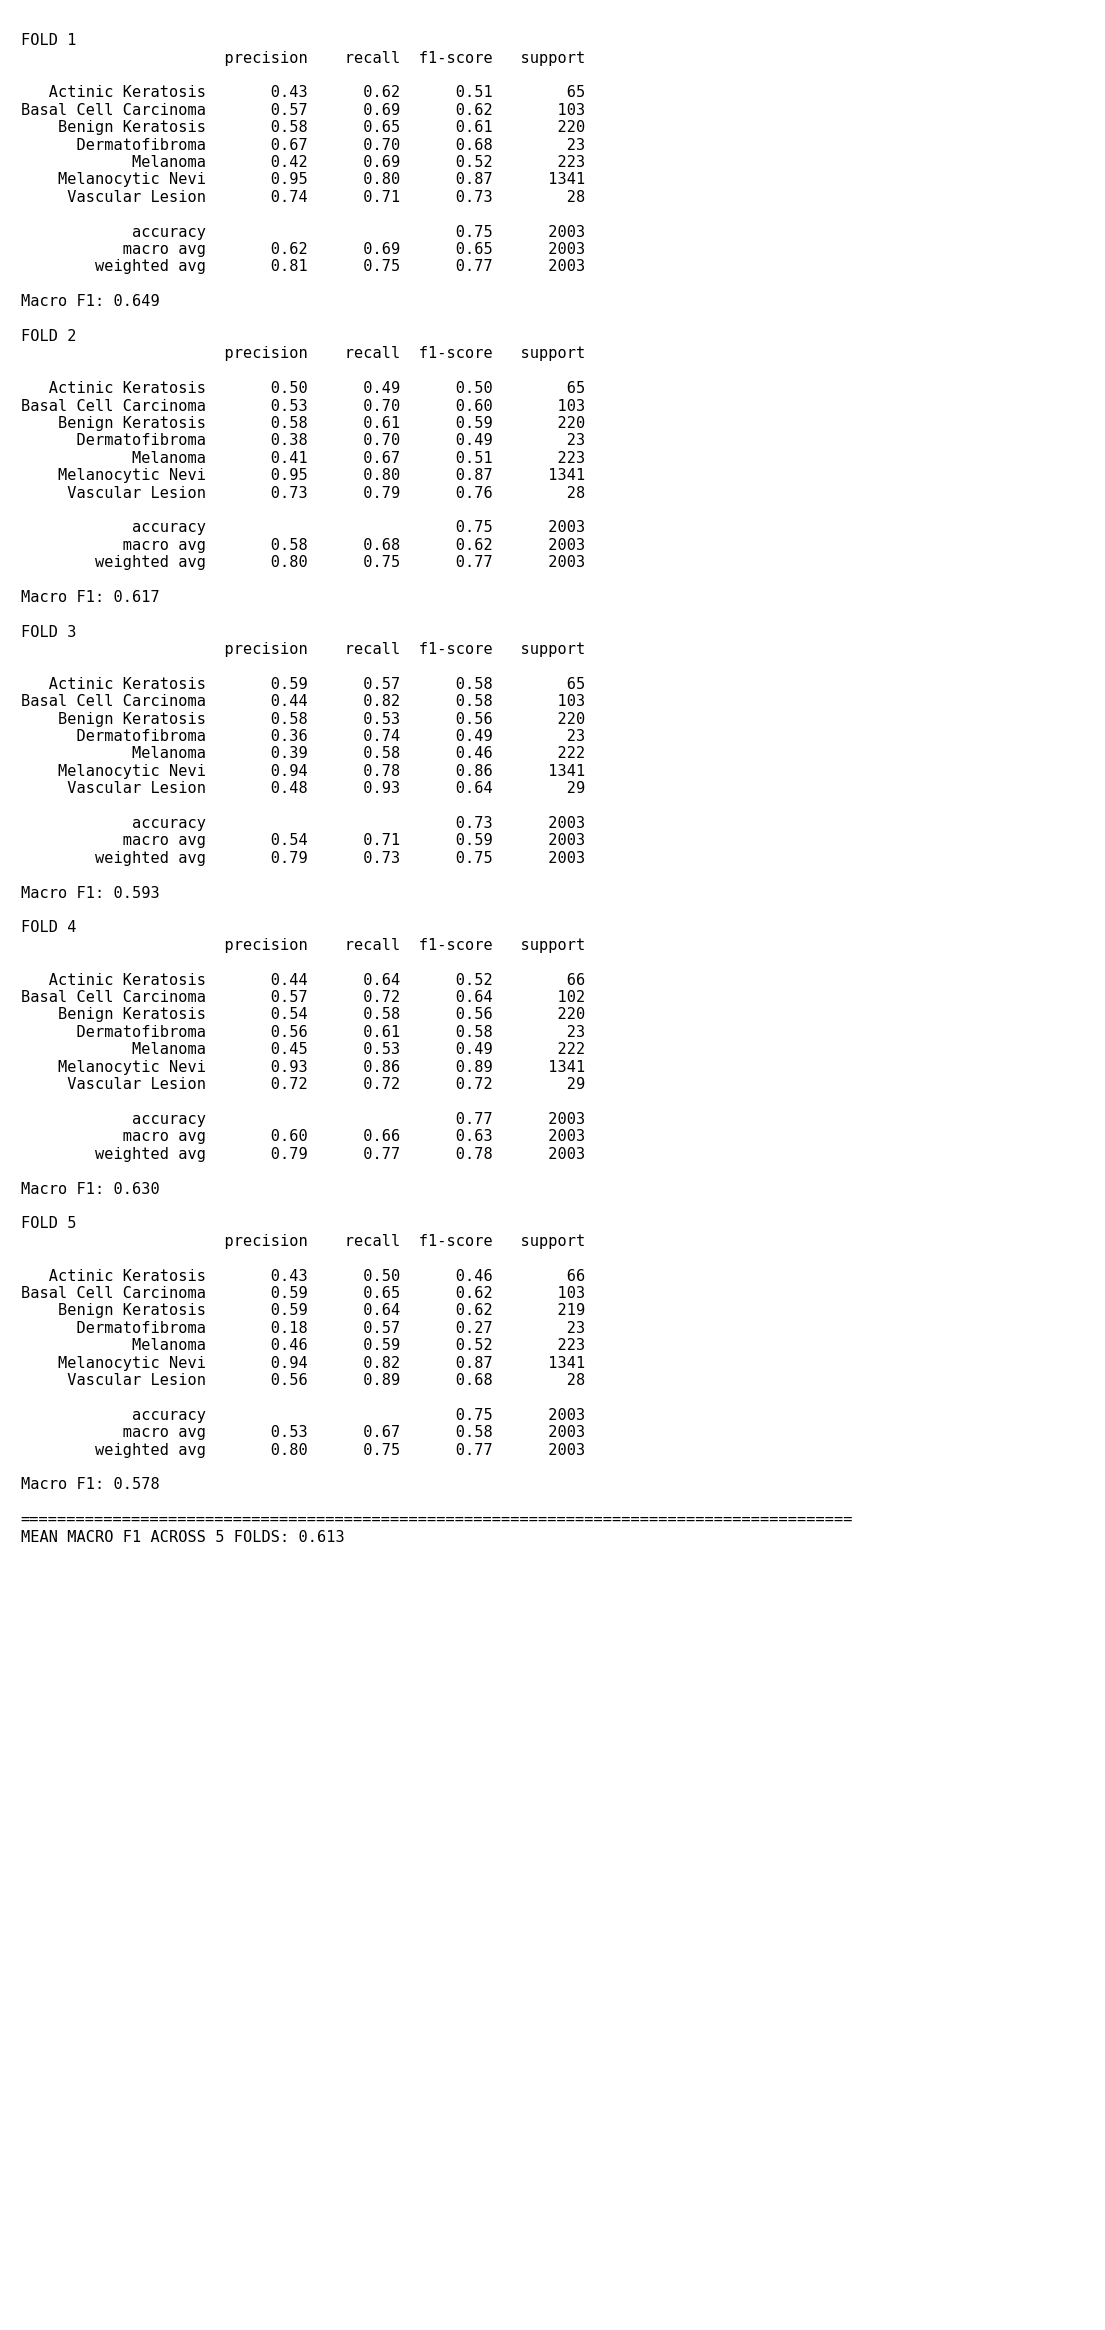

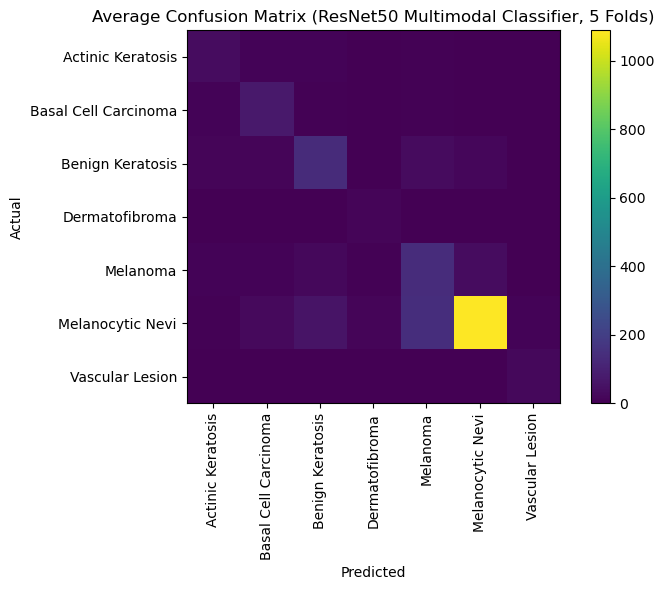

In [129]:
all_macro_f1 = []
all_reports = []
all_cm = []

class_names = le.classes_
num_classes = len(class_names)

label_map = {
    "akiec": "Actinic Keratosis",
    "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic Nevi",
    "vasc": "Vascular Lesion"
}

for i, fold in enumerate(folds):
    print(f"\n--- Fold {i+1} ---")

    X_img_train = fold["X_img_train"].tolist()
    X_img_val = fold["X_img_val"].tolist()

    X_train_img_features = extract_features_batch(X_img_train, batch_size=16)
    X_val_img_features = extract_features_batch(X_img_val, batch_size=16)


    X_train_meta = fold["X_meta_train"].to_numpy(dtype=np.float32)
    X_val_meta = fold["X_meta_val"].to_numpy(dtype=np.float32)

    scaler = StandardScaler()
    X_train_meta_scaled = scaler.fit_transform(X_train_meta)
    X_val_meta_scaled = scaler.transform(X_val_meta)


    X_train_combined = np.concatenate([X_train_img_features, X_train_meta_scaled], axis=1)
    X_val_combined = np.concatenate([X_val_img_features, X_val_meta_scaled], axis=1)


    y_train = fold["y_train"].to_numpy()
    y_val = fold["y_val"].to_numpy()

    classes = np.unique(y_train)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    class_weights = dict(zip(classes, weights))

    classifier = keras.Sequential([
        keras.Input(shape=(X_train_combined.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    classifier.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = classifier.fit(
        X_train_combined,
        y_train,
        validation_data=(X_val_combined, y_val),
        epochs=50,
        batch_size=32,
        verbose=1,
        class_weight=class_weights,
        callbacks=[early_stop]
    )

    y_pred = classifier.predict(X_val_combined)
    y_pred_classes = np.argmax(y_pred, axis=1)

    report = classification_report(
        y_val,
        y_pred_classes,
        target_names=[label_map[name] for name in class_names]
    )

    macro_f1 = f1_score(y_val, y_pred_classes, average="macro")
    all_macro_f1.append(macro_f1)

    fold_report = f"FOLD {i+1}\n{report}\nMacro F1: {macro_f1:.3f}"
    all_reports.append(fold_report)

    cm = confusion_matrix(y_val, y_pred_classes)
    all_cm.append(cm)

# SUMMARY REPORT
mean_macro_f1 = np.mean(all_macro_f1)

summary_text = "\n\n".join(all_reports)
summary_text += f"\n\n{'=' * 90}\nMEAN MACRO F1 ACROSS 5 FOLDS: {mean_macro_f1:.3f}"

plt.figure(figsize=(14, 30))
plt.text(
    0.01,
    0.99,
    summary_text,
    fontsize=11,
    family="monospace",
    va="top"
)
plt.axis("off")

plt.savefig(
    "../outputs/classification_reports/resnet_multimodal_5fold_summary.png",
    bbox_inches="tight",
    pad_inches=0.4,
    dpi=300
)

plt.close()

# CONFUSION MATRIX
mean_cm = np.mean(all_cm, axis=0)

plt.figure(figsize=(8, 6))
plt.imshow(mean_cm)
plt.title("Average Confusion Matrix (ResNet50 Multimodal Classifier, 5 Folds)")
plt.colorbar()
plt.xticks(
    range(len(class_names)),
    [label_map[c] for c in class_names],
    rotation=90
)
plt.yticks(
    range(len(class_names)),
    [label_map[c] for c in class_names]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(
    "../outputs/confusion_matrices/resnet_multimodal_confusion_matrix_5fold_average.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

# Image-Only Classifier

## Stratified K-Fold Cross-Validation

In [130]:
y = df_model["dx"]
X_images = df_model["image_path"]

print("Images:", X_images.shape)
print("dx:", y.shape)

Images: (10015,)
dx: (10015,)


In [132]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
folds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_images, y), start=1):
    fold_data = {
        "fold": fold,
        "X_img_train": X_images.iloc[train_idx].reset_index(drop=True),
        "X_img_val": X_images.iloc[val_idx].reset_index(drop=True),
        "y_train": y.iloc[train_idx].reset_index(drop=True),
        "y_val": y.iloc[val_idx].reset_index(drop=True)
    }
    folds.append(fold_data)
print("Number of folds saved:", len(folds))

Number of folds saved: 5


## Image Preprocessing and Feature Extraction

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
    pooling="avg"
)

print("Model loaded")

Model loaded


In [ ]:
"""
def extract_features(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))

    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    features = base_model.predict(img_array, verbose=0)
    return features[0]
"""

In [ ]:
"""
def load_and_preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    return preprocess_input(img_array)
"""

def extract_features_batch(image_paths, batch_size=32):
    all_features = []
    
    for start in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[start:start + batch_size]
        batch_images = np.array([load_and_preprocess_image(p) for p in batch_paths])
        
        batch_features = base_model.predict(batch_images, verbose=0)
        all_features.append(batch_features)
        
    
    return np.vstack(all_features)

## Image-Only Classifier and Evaluation


--- Fold 1 ---
Processed 16 / 8012
Processed 32 / 8012
Processed 48 / 8012
Processed 64 / 8012
Processed 80 / 8012
Processed 96 / 8012
Processed 112 / 8012
Processed 128 / 8012
Processed 144 / 8012
Processed 160 / 8012
Processed 176 / 8012
Processed 192 / 8012
Processed 208 / 8012
Processed 224 / 8012
Processed 240 / 8012
Processed 256 / 8012
Processed 272 / 8012
Processed 288 / 8012
Processed 304 / 8012
Processed 320 / 8012
Processed 336 / 8012
Processed 352 / 8012
Processed 368 / 8012
Processed 384 / 8012
Processed 400 / 8012
Processed 416 / 8012
Processed 432 / 8012
Processed 448 / 8012
Processed 464 / 8012
Processed 480 / 8012
Processed 496 / 8012
Processed 512 / 8012
Processed 528 / 8012
Processed 544 / 8012
Processed 560 / 8012
Processed 576 / 8012
Processed 592 / 8012
Processed 608 / 8012
Processed 624 / 8012
Processed 640 / 8012
Processed 656 / 8012
Processed 672 / 8012
Processed 688 / 8012
Processed 704 / 8012
Processed 720 / 8012
Processed 736 / 8012
Processed 752 / 8012
Pro

2026-04-12 18:16:58.465254: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Processed 8012 / 8012
Processed 16 / 2003
Processed 32 / 2003
Processed 48 / 2003
Processed 64 / 2003
Processed 80 / 2003
Processed 96 / 2003
Processed 112 / 2003
Processed 128 / 2003
Processed 144 / 2003
Processed 160 / 2003
Processed 176 / 2003
Processed 192 / 2003
Processed 208 / 2003
Processed 224 / 2003
Processed 240 / 2003
Processed 256 / 2003
Processed 272 / 2003
Processed 288 / 2003
Processed 304 / 2003
Processed 320 / 2003
Processed 336 / 2003
Processed 352 / 2003
Processed 368 / 2003
Processed 384 / 2003
Processed 400 / 2003
Processed 416 / 2003
Processed 432 / 2003
Processed 448 / 2003
Processed 464 / 2003
Processed 480 / 2003
Processed 496 / 2003
Processed 512 / 2003
Processed 528 / 2003
Processed 544 / 2003
Processed 560 / 2003
Processed 576 / 2003
Processed 592 / 2003
Processed 608 / 2003
Processed 624 / 2003
Processed 640 / 2003
Processed 656 / 2003
Processed 672 / 2003
Processed 688 / 2003
Processed 704 / 2003
Processed 720 / 2003
Processed 736 / 2003
Processed 752 / 20

2026-04-12 18:18:08.281512: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4009 - loss: 1.7696

...

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Fold 4 ---
Processed 16 / 8012
Processed 32 / 8012
Processed 48 / 8012
Processed 64 / 8012
Processed 80 / 8012
Processed 96 / 8012
Processed 112 / 8012
Processed 128 / 8012
Processed 144 / 8012
Processed 160 / 8012
Processed 176 / 8012
Processed 192 / 8012
Processed 208 / 8012
Processed 224 / 8012
Processed 240 / 8012
Processed 256 / 8012
Processed 272 / 8012
Processed 288 / 8012
Processed 304 / 8012
Processed 320 / 8012
Processed 336 / 8012
Processed 352 / 8012
Processed 368 / 8012
Processed 384 / 8012
Processed 400 / 8012
Processed 416 / 8012
Processed 432 / 8012
Processed 448 / 8012
Processed 464 / 8012
Processed 480 / 8012
Processed 496 / 8012
Processed 512 / 8012
Processed 528 / 8012
Processed 544 / 8012
Processed 560 / 8012
Processed 576 / 8012
Processed 592 / 8012
Processed 608 / 8012
Processed 624 / 8012
Processed 640 / 8012
Processed 656 / 8012
Processed 672 / 8012
Processed 688 / 8012
Processed 704 / 8012
Processed 720 / 8012
Proces

2026-04-12 19:48:09.245950: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4436 - loss: 1.6452 - val_accuracy: 0.4149 - val_loss: 1.5229
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5459 - loss: 1.2265 - val_accuracy: 0.6121 - val_loss: 1.0146
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5708 - loss: 1.0969 - val_accuracy: 0.5876 - val_loss: 1.0483
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5859 - loss: 0.9877 - val_accuracy: 0.6695 - val_loss: 0.8593
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5895 - loss: 0.9451 - val_accuracy: 0.6620 - val_loss: 0.8492
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6132 - loss: 0.8556 - val_accuracy: 0.6820 - val_loss: 0.8241
Epoch 7/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6232 - loss: 0.8243 - val_accuracy: 0.7204 - val_loss: 0.7640
Epoch 8/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6287 - loss: 0.8254 - val_accuracy: 0.6086 - val

2026-04-12 19:52:04.806803: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4261 - loss: 1.5758 - val_accuracy: 0.5801 - val_loss: 1.1507
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5334 - loss: 1.2362 - val_accuracy: 0.5836 - val_loss: 1.0620
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5733 - loss: 1.0900 - val_accuracy: 0.5921 - val_loss: 1.0654
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6042 - loss: 1.0002 - val_accuracy: 0.6905 - val_loss: 0.8714
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6108 - loss: 0.9491 - val_accuracy: 0.7284 - val_loss: 0.7502
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6297 - loss: 0.8847 - val_accuracy: 0.6550 - val_loss: 0.8677
Epoch 7/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6365 - loss: 0.8143 - val_accuracy: 0.6810 - val_loss: 0.7641
Epoch 8/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6435 - loss: 0.8102 - val_accuracy: 0.6455 - va

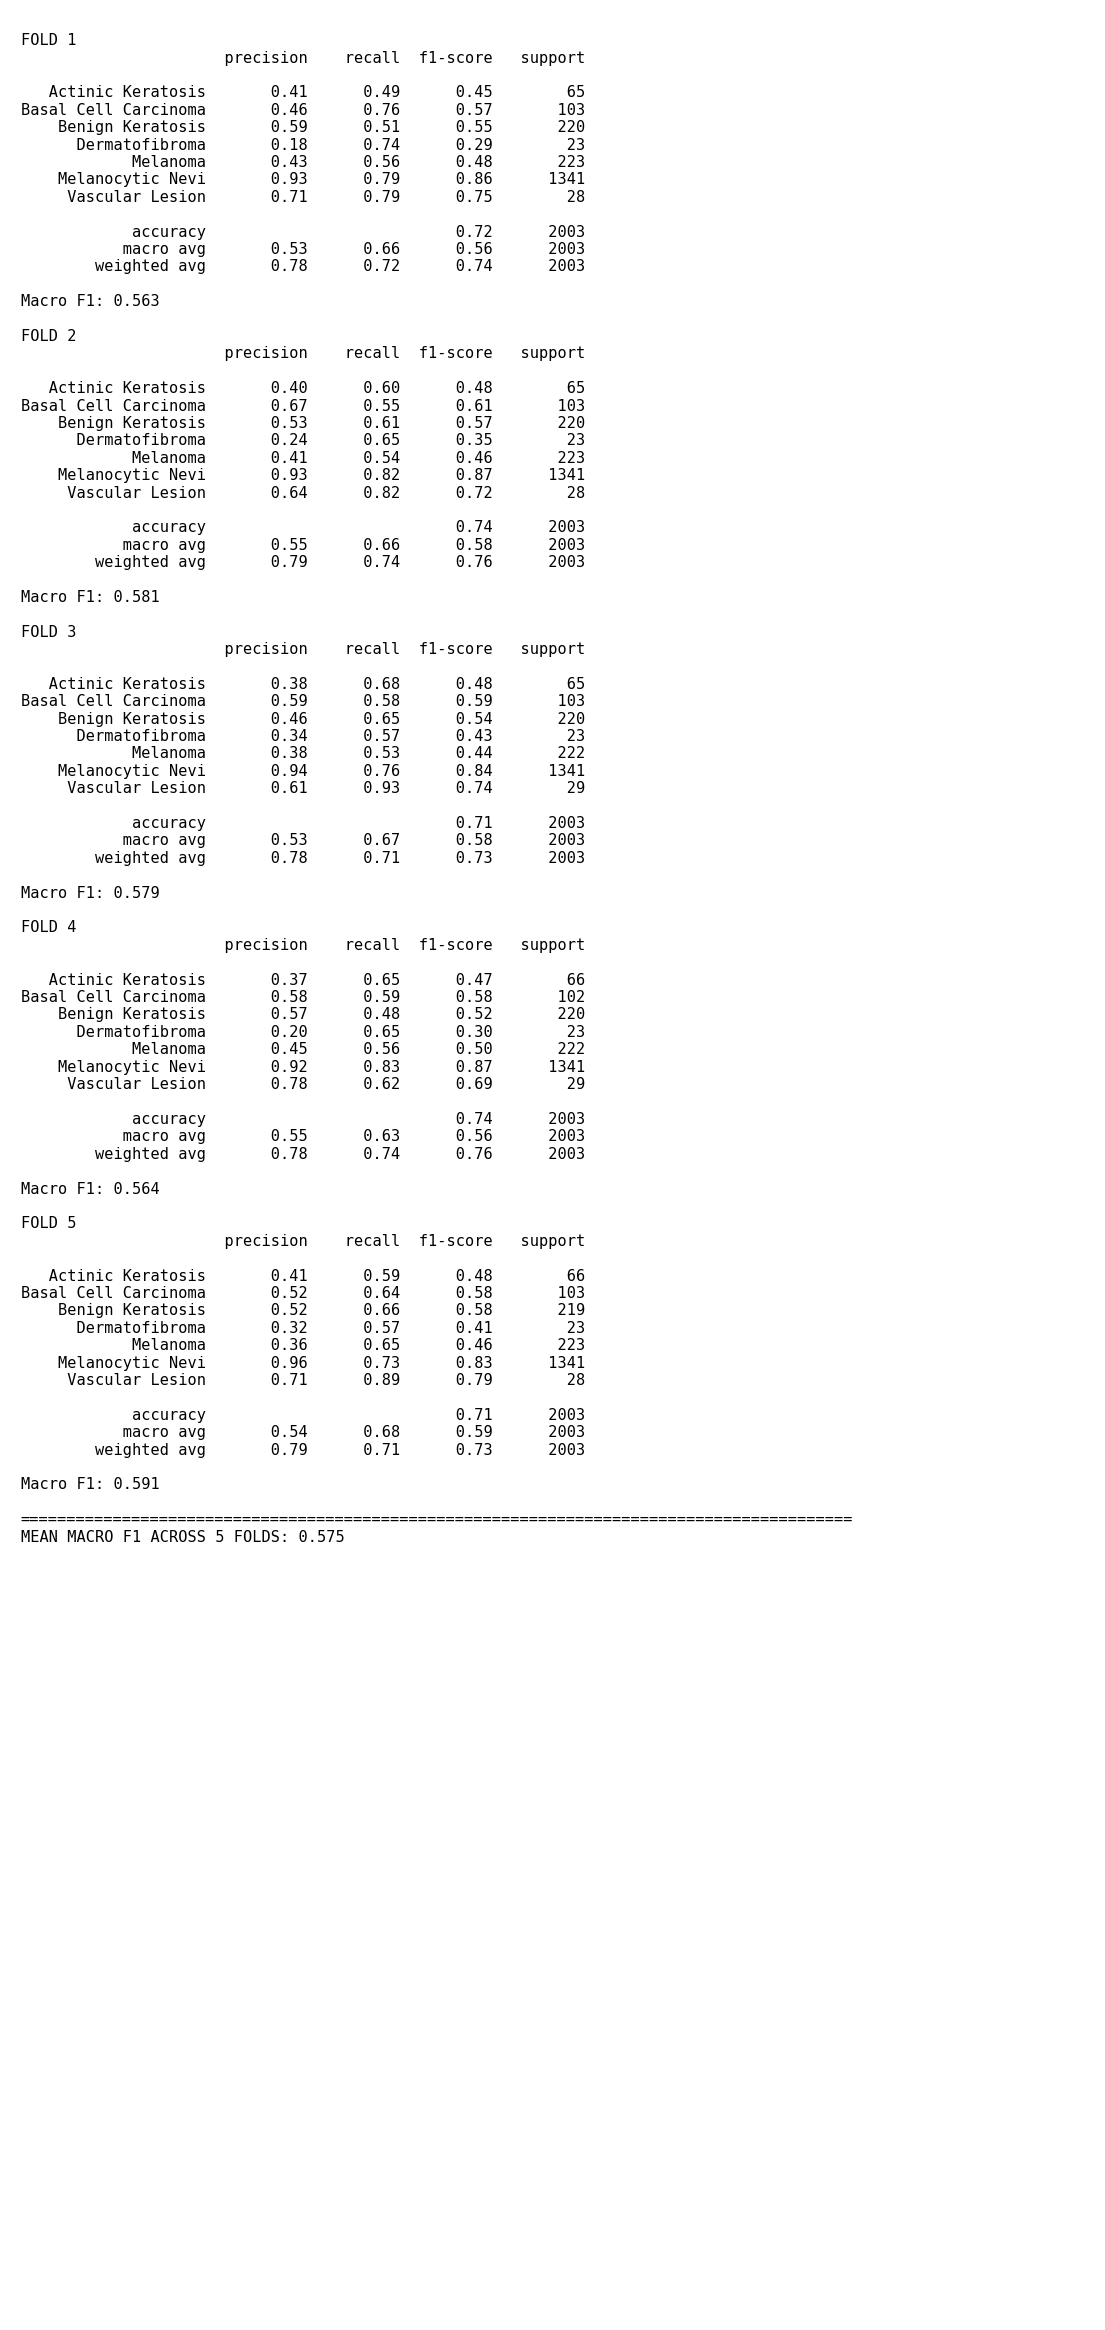

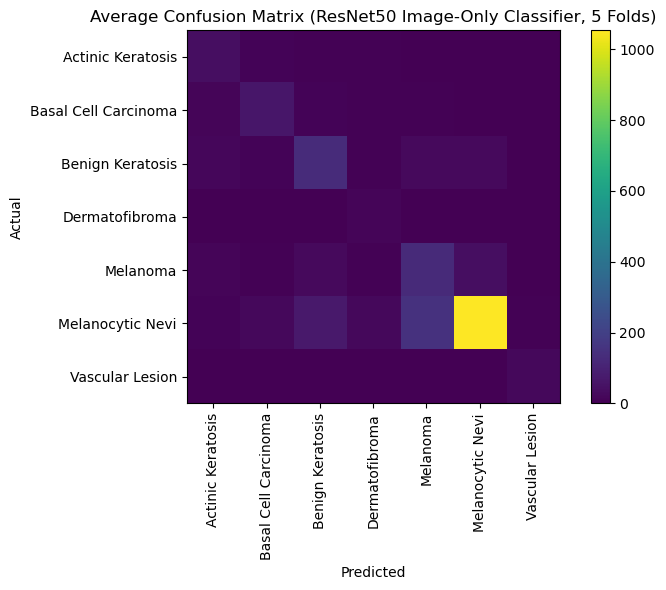

In [ ]:
all_macro_f1 = []
all_reports = []
all_cm = []

class_names = le.classes_

label_map = {
    "akiec": "Actinic Keratosis",
    "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic Nevi",
    "vasc": "Vascular Lesion"
}

for i, fold in enumerate(folds):

    X_img_train = fold["X_img_train"].tolist()
    X_img_val = fold["X_img_val"].tolist()

    X_train_img_features = extract_features_batch(X_img_train, batch_size=16)
    X_val_img_features = extract_features_batch(X_img_val, batch_size=16)

    y_train = fold["y_train"].to_numpy()
    y_val = fold["y_val"].to_numpy()

    classes = np.unique(y_train)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    class_weights = dict(zip(classes, weights))

    classifier = keras.Sequential([
        keras.Input(shape=(X_train_img_features.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(len(class_names), activation="softmax")
    ])

    classifier.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = classifier.fit(
        X_train_img_features,
        y_train,
        validation_data=(X_val_img_features, y_val),
        epochs=50,
        batch_size=32,
        verbose=1,
        class_weight=class_weights,
        callbacks=[early_stop]
    )

    y_pred = classifier.predict(X_val_img_features)
    y_pred_classes = np.argmax(y_pred, axis=1)

    report = classification_report(
        y_val,
        y_pred_classes,
        target_names=[label_map[name] for name in class_names]
    )

    macro_f1 = f1_score(y_val, y_pred_classes, average="macro")
    all_macro_f1.append(macro_f1)

    fold_report = f"FOLD {i+1}\n{report}\nMacro F1: {macro_f1:.3f}"
    all_reports.append(fold_report)

    cm = confusion_matrix(y_val, y_pred_classes)
    all_cm.append(cm)

# 1) SUMMARY REPORT
mean_macro_f1 = np.mean(all_macro_f1)

summary_text = "\n\n".join(all_reports)
summary_text += f"\n\n{'=' * 90}\nMEAN MACRO F1 ACROSS 5 FOLDS: {mean_macro_f1:.3f}"

plt.figure(figsize=(14, 30))
plt.text(
    0.01,
    0.99,
    summary_text,
    fontsize=11,
    family="monospace",
    va="top"
)
plt.axis("off")

plt.savefig(
    "outputs/classification_reports/resnet_image_only_5fold_summary.png",
    bbox_inches="tight",
    pad_inches=0.4,
    dpi=300
)

plt.close()

# 2) CONFUSION MATRIX
mean_cm = np.mean(all_cm, axis=0)

plt.figure(figsize=(8, 6))
plt.imshow(mean_cm)
plt.title("Average Confusion Matrix (ResNet50 Image-Only Classifier, 5 Folds)")
plt.colorbar()
plt.xticks(
    range(len(class_names)),
    [label_map[name] for name in class_names],
    rotation=90
)
plt.yticks(
    range(len(class_names)),
    [label_map[name] for name in class_names]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(
    "../outputs/confusion_matrices/resnet_image_only_confusion_matrix_5fold_average.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()